# 02 — Seasonal decomposition (daily load)

Loads hourly DE_LU load from Parquet, aggregates to **daily mean** MW, then runs **`statsmodels.tsa.seasonal.seasonal_decompose`** with **`model="additive"`**.

`seasonal_decompose` needs a fixed seasonal **`period`** (in days): **`7`** captures week-of-year pattern; **`365`** approximates annual seasonality (needs enough history, ideally ≥ 2×365 daily points).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss


In [2]:
# Default: your machine path; falls back to repo-relative if missing
DATA_PATH = Path(r"C:\Users\mhmta\Cursor_Study\energy-ts-fundamentals\data\raw\de_lu_load_hourly.parquet")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/raw/de_lu_load_hourly.parquet")

load_hourly = pd.read_parquet(DATA_PATH)
idx = load_hourly.index
if not isinstance(idx, pd.DatetimeIndex):
    load_hourly.index = pd.to_datetime(idx, utc=True)
if load_hourly.index.tz is None:
    load_hourly.index = load_hourly.index.tz_localize(
        "Europe/Berlin", ambiguous="infer", nonexistent="shift_forward"
    )
else:
    load_hourly.index = load_hourly.index.tz_convert("Europe/Berlin")

daily = load_hourly["load_mw"].resample("1D").mean().dropna() #  .resample("1D"): This is a powerful pandas method for resampling time series data. It groups the data by a specified frequency, in this case, "1D" means '1 Day'. Since load_hourly has a DatetimeIndex, resample() understands how to group the hourly data into daily intervals.
daily.name = "load_mw_daily_mean"
print(f"Daily rows: {len(daily):,} | {daily.index.min().date()} → {daily.index.max().date()}")
daily.head()

Daily rows: 1,096 | 2023-01-01 → 2025-12-31


2023-01-01 00:00:00+01:00    41536.462396
2023-01-02 00:00:00+01:00    52297.668229
2023-01-03 00:00:00+01:00    54458.059271
2023-01-04 00:00:00+01:00    58895.381042
2023-01-05 00:00:00+01:00    56186.779062
Freq: D, Name: load_mw_daily_mean, dtype: float64

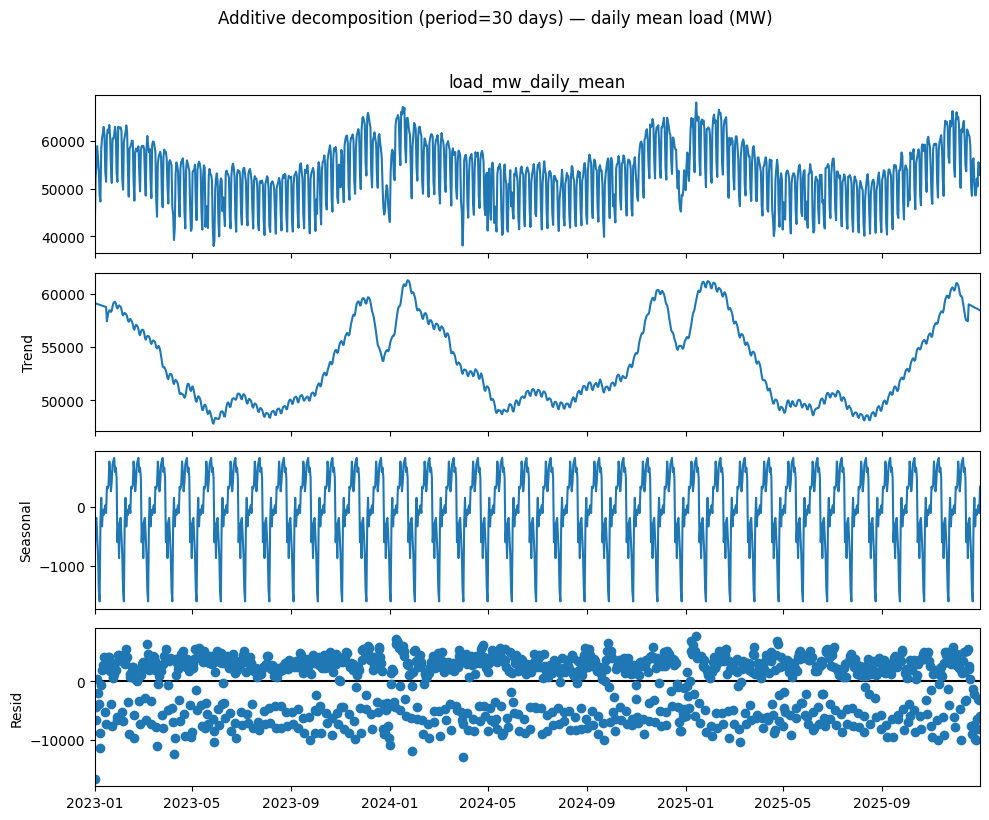

In [7]:
SEASONAL_PERIOD = 30  # days; try 365 for yearly cycle (needs long enough series)

decomp = seasonal_decompose(
    daily,
    model="additive", # This specifies that an additive model should be used. In an additive model, the components (trend, seasonal, and residual) are summed together to reconstruct the original series (i.e., Y = Trend + Seasonal + Residual)
    period=SEASONAL_PERIOD, #  tells the function the number of data points in a single seasonal cycle. 
    extrapolate_trend="freq", # This argument handles how the trend component is estimated at the beginning and end of the series. When set to "freq", it uses the frequency of the series to extrapolate the trend, which helps in getting a more complete trend component, especially for short series or when the trend calculation might otherwise leave NaNs at the edges.
)

fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.suptitle(
    f"Additive decomposition (period={SEASONAL_PERIOD} days) — daily mean load (MW)",
    y=1.02,
)
plt.tight_layout()
plt.show()

## STL on hourly load

**STL** (Seasonal–Trend using Loess) on **`load_mw`** at native hourly resolution:

| `period` | Meaning |
|----------|---------|
| **24** | Intraday / calendar-day cycle (hours 0–23) |
| **168** | Weekly cycle (7 × 24 hours) |

The hourly index is reindexed to a strict **`1h`** grid and short gaps are **interpolated** so STL sees an evenly spaced series.

In [4]:
hourly = (
    load_hourly["load_mw"]
    .astype(float) # This converts the data type of the load_mw series to float. This is a good practice to ensure numerical operations can be performed correctly and to handle any mixed data types that might have crept in.
    .sort_index() # This sorts the series by its index (which is a DatetimeIndex).
    .asfreq("1h") # This resamples the series to a strict hourly frequency ("1h"). If there are gaps (missing hours), asfreq will insert NaN values for those hours. If there are multiple entries for the same hour (which shouldn't happen with the original data's structure, but is good to ensure), it would pick one or require an aggregation method (which is not specified here, implying strict alignment).
    .interpolate(limit_direction="both") # This is used to fill any NaN values introduced by asfreq or existing in the data. interpolate() estimates missing values based on adjacent valid data points. limit_direction="both" means it will interpolate both forwards and backwards from valid data, helping to fill gaps at the beginning or end of the series as well.
)
hourly.name = "load_mw"
print(f"Hourly rows: {len(hourly):,} | {hourly.index.min()} → {hourly.index.max()}")

Hourly rows: 26,304 | 2023-01-01 00:00:00+01:00 → 2025-12-31 23:00:00+01:00


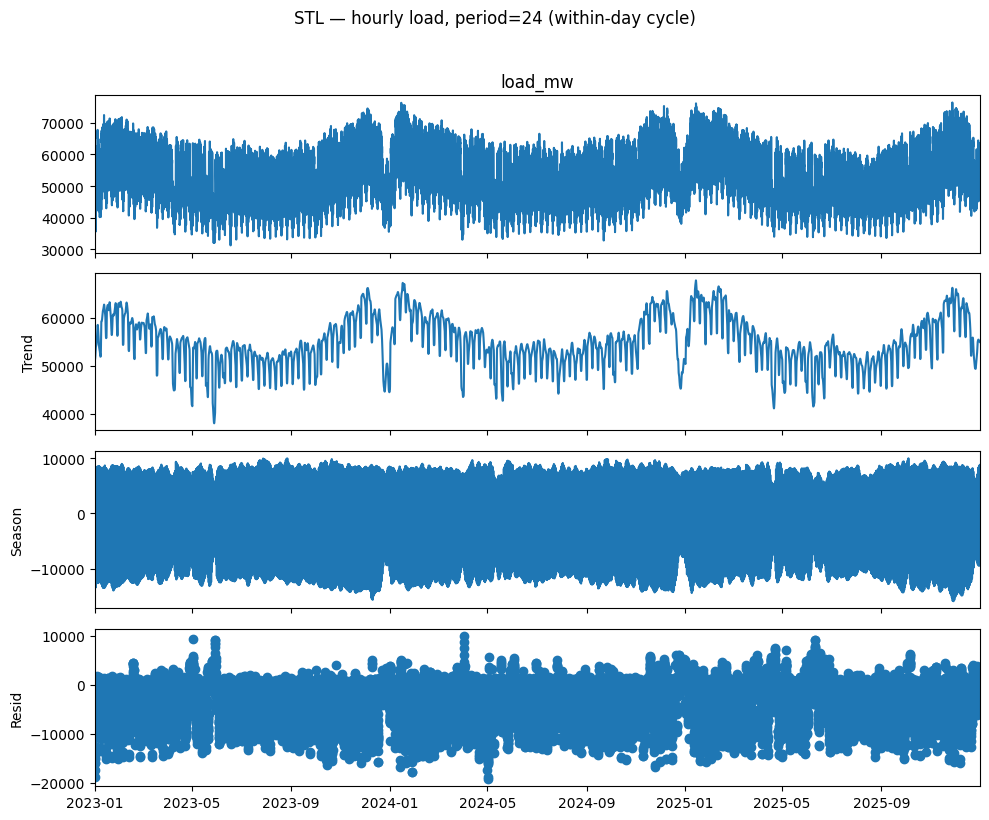

In [ ]:
stl_24 = STL( # Seasonal-Trend decomposition using LOESS (STL) is a robust statistical method for decomposing time series data into three components: trend, seasonality, and remainder (residuals). It utilizes LOESS (locally estimated scatterplot smoothing) to iteratively estimate non-linear relationships, allowing for flexible, changing seasonality and trend patterns
period=24, #  This is a crucial parameter. It specifies the length of the seasonal cycle. Since your hourly data is sampled hourly, a period=24 indicates a daily seasonality (i.e., a pattern that repeats every 24 hours).
robust=True #  This parameter makes the STL decomposition robust to outliers. When robust is set to True, the smoothing steps are performed in a way that minimizes the influence of unusual observations on the trend and seasonal components.
).fit()

fig = stl_24.plot()
fig.set_size_inches(10, 8)
fig.suptitle("STL — hourly load, period=24 (within-day cycle)", y=1.02)
plt.tight_layout()
plt.show()

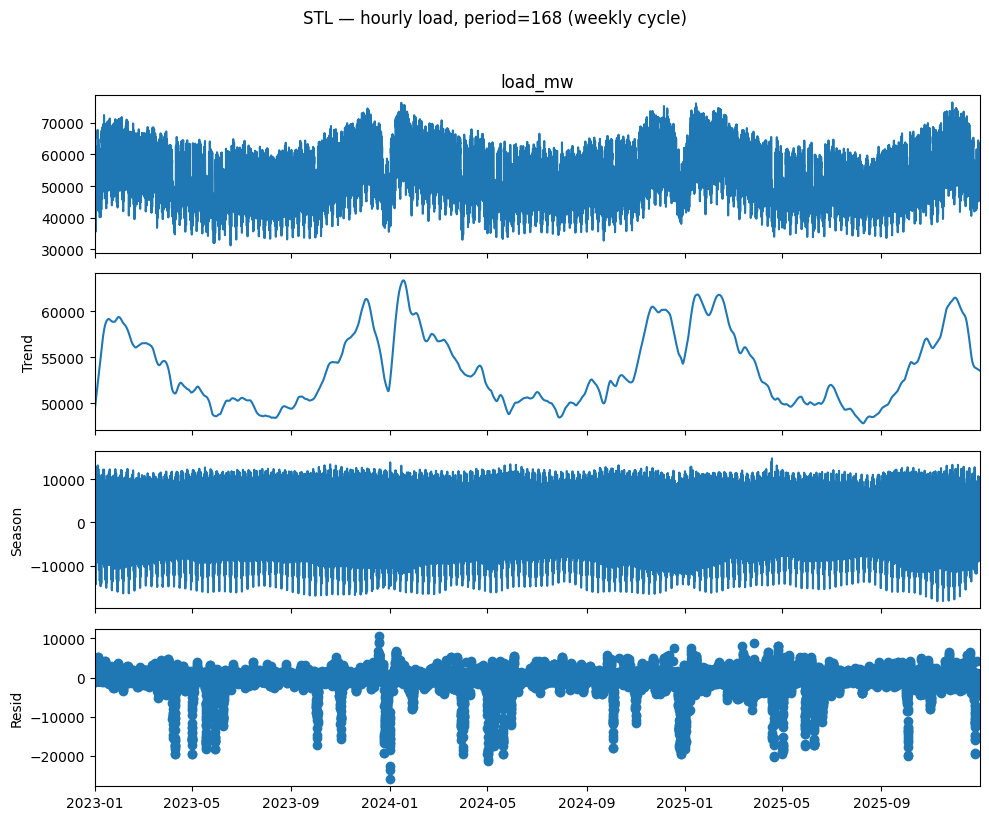

In [17]:
stl_168 = STL(hourly, period=168, robust=True).fit()

fig = stl_168.plot()
fig.set_size_inches(10, 8)
fig.suptitle("STL — hourly load, period=168 (weekly cycle)", y=1.02)
plt.tight_layout()
plt.show()

## Unit-root tests (hourly series)

**ADF** (Augmented Dickey–Fuller): *H₀* = unit root (non-stationary). Small *p* → reject *H₀* → evidence of stationarity.

**KPSS** (Kwiatkowski–Phillips–Schmidt–Shin, `regression='c'`): *H₀* = stationary around a constant. Small *p* → reject *H₀* → evidence of non-stationarity.

The two tests do not share the same *H₀*; they can disagree at the margin.

**Transforms** (applied in order on `hourly`):

1. First difference: \((1-B)y_t = y_t - y_{t-1}\)
2. Seasonal difference at **24**: \((1-B^{24})\) on the result
3. Seasonal difference at **168**: \((1-B^{168})\) on the result

We report ADF and KPSS on **levels**, then after each differencing step.

The line `adf_stat, adf_p, adf_lag, adf_nobs, adf_crit, _ = adfuller(s, autolag="AIC")` performs an** Augmented Dickey-Fuller (ADF) test**, which is a statistical test used to determine if a time series is stationary. Here's a breakdown of the variables it returns:

- adf_stat: The ADF test statistic. A more negative value indicates stronger evidence against the null hypothesis (that the series has a unit root).
- adf_p: The p-value associated with the ADF test statistic. If this value is less than a chosen significance level (e.g., 0.05), you can reject the null hypothesis and conclude that the series is stationary.
- adf_lag: The number of lags used in the ADF regression. 
- adf_crit: A dictionary of critical values for the test statistic at different significance levels (e.g., 1%, 5%, 10%). You compare the adf_stat to these critical values to determine stationarity.
- _: This placeholder (underscore) captures any additional return values that are not needed for this specific analysis. In this case, the adfuller function returns a sixth value, which is usually the regression results, but it's ignored here.

The line `kpss_stat, kpss_p, kpss_lag, kpss_crit = kpss(s, regression="c", nlags="auto")` performs a **Kwiatkowski-Phillips-Schmidt-Shin (KPSS)** test, which is another statistical test used to determine if a time series is stationary around a deterministic trend (or level, in this case). Unlike the ADF test, the null hypothesis for the KPSS test is that the series is stationary. Here's a breakdown of the variables it returns:

- kpss_stat: The KPSS test statistic. A larger value indicates stronger evidence against the null hypothesis (that the series is stationary).
- kpss_p: The p-value associated with the KPSS test statistic. If this value is less than a chosen significance level (e.g., 0.05), you can reject the null hypothesis and conclude that the series is non-stationary.
- kpss_lag: The number of lags used in the KPSS regression.
- kpss_crit: A dictionary of critical values for the test statistic at different significance levels (e.g., 1%, 5%, 10%). You compare the kpss_stat to these critical values to determine stationarity.

In [ ]:
import warnings # the built-in Python warnings module. This module provides functions and utilities to manage warnings in Python code. It allows developers to issue warnings, control how warnings are displayed, and filter them.


def unit_root_report(name: str, s: pd.Series) -> None:
    s = pd.Series(s, dtype=float).dropna()
    print(f"\n{'=' * 60}\n{name}\n  n = {len(s):,}\n{'=' * 60}")

    adf_stat, adf_p, adf_lag, adf_nobs, adf_crit, _ = adfuller(s, autolag="AIC")
    print(
        f"ADF: statistic = {adf_stat:.6f}, p-value = {adf_p:.6g}, "
        f"used lag = {adf_lag}, nobs = {adf_nobs}"
    )
    print("  H0: unit root. Reject H0 (p < 0.05) → stationary.")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=Warning)
        kpss_stat, kpss_p, kpss_lag, kpss_crit = kpss(s, regression="c", nlags="auto")
    print(
        f"KPSS: statistic = {kpss_stat:.6f}, p-value = {kpss_p:.6g}, "
        f"used lags = {kpss_lag}"
    )
    print("  H0: level stationarity. Reject H0 (p < 0.05) → non-stationary.")


y = hourly.astype(float)
d1 = y.diff(1)
d1_s24 = d1.diff(24)
d1_s24_s168 = d1_s24.diff(168)

unit_root_report("Hourly levels", y)
unit_root_report("After first difference (1-B)", d1)
unit_root_report("After + seasonal diff lag 24: (1-B)(1-B^24)", d1_s24)
unit_root_report("After + seasonal diff lag 168: (1-B)(1-B^24)(1-B^168)", d1_s24_s168)


Hourly levels
  n = 26,304
ADF: statistic = -15.013653, p-value = 1.04663e-27, used lag = 49, nobs = 26254
  H0: unit root. Reject H0 (p < 0.05) → stationary.
KPSS: statistic = 0.507748, p-value = 0.0399216, used lags = 75
  H0: level stationarity. Reject H0 (p < 0.05) → non-stationary.

After first difference (1-B)
  n = 26,303
ADF: statistic = -26.146865, p-value = 0, used lag = 49, nobs = 26253
  H0: unit root. Reject H0 (p < 0.05) → stationary.
KPSS: statistic = 0.008974, p-value = 0.1, used lags = 247
  H0: level stationarity. Reject H0 (p < 0.05) → non-stationary.

After + seasonal diff lag 24: (1-B)(1-B^24)
  n = 26,279
ADF: statistic = -38.717506, p-value = 0, used lag = 49, nobs = 26229
  H0: unit root. Reject H0 (p < 0.05) → stationary.
KPSS: statistic = 0.000800, p-value = 0.1, used lags = 44
  H0: level stationarity. Reject H0 (p < 0.05) → non-stationary.

After + seasonal diff lag 168: (1-B)(1-B^24)(1-B^168)
  n = 26,111
ADF: statistic = -38.040448, p-value = 0, used lag 

- Multiple Seasonalities: Electricity load (and many other real-world time series) often exhibits clear patterns at different frequencies. For example, daily cycles (peak load during the day, lower at night), weekly cycles (lower demand on weekends), and yearly cycles (higher demand in summer/winter, lower in spring/fall). These distinct patterns occur simultaneously.

- Limitations of Single-Period Decomposition: Standard seasonal decomposition methods like seasonal_decompose in statsmodels (which we used earlier with period=7) are typically designed to identify and remove one dominant seasonal component. If you apply it with period=7 to data with daily and yearly cycles, it will only address the weekly pattern, and the other seasonalities will remain intertwined in the trend or residual components.

- Need for Specialized Models: Because single-period decomposition simplifies the reality of multiple seasonal patterns, it's often insufficient for accurate forecasting or understanding. This is precisely why more advanced models are developed, such as:

    - MSTL (Multiple Seasonal-Trend decomposition using Loess): An extension of STL that can handle multiple seasonal periods simultaneously.
    - Prophet (Facebook's forecasting tool): Designed to model multiple seasonalities (daily, weekly, yearly) with ease.
    - SARIMAX (Seasonal Autoregressive Integrated Moving Average with eXogenous regressors): Can be configured with multiple seasonal orders to capture different periodicities.
Internalizing this concept is vital because ignoring multiple seasonalities can lead to biased forecasts, inaccurate estimations of trend, and residuals that still contain predictable patterns, indicating a suboptimal model. It undersc